[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1opf1igX6pKVYlLkD0dJ5XkbLwdW-sbWw)

## mBERT un XLM-RoBERTa apmācība

In [65]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    BertForSequenceClassification,
    BertTokenizer,
    Trainer,
    TrainingArguments,
    XLMRobertaForSequenceClassification,
    XLMRobertaTokenizer
)

In [51]:
!wget -q -O data.csv https://raw.githubusercontent.com/IvoDz/lv-text-complexity/refs/heads/main/data.csv

In [52]:
df = pd.read_csv("data.csv")
label_map = {"viegls": 0, "vidējs": 1, "sarežģīts": 2}
df["level"] = df["level"].map(label_map)

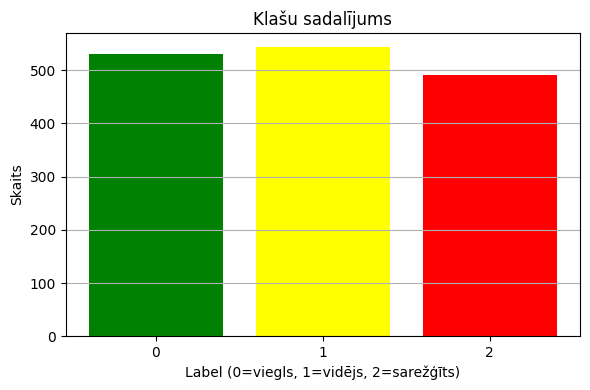

In [54]:
label_counts = df["level"].value_counts().sort_index()
colors = ['green', 'yellow', 'red']
plt.figure(figsize=(6, 4))
plt.bar(label_counts.index.astype(str), label_counts.values, color=colors)
plt.xlabel("Label (0=viegls, 1=vidējs, 2=sarežģīts)")
plt.ylabel("Skaits")
plt.title("Klašu sadalījums")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [55]:
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["level"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["level"], random_state=42)

### mBERT
# model = BertForSequenceClassification.from_pretrained('bert-base-multilingual-cased', num_labels=3)
# tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

model = XLMRobertaForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=3)
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')

ds = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'validation': Dataset.from_pandas(val_df),
    'test': Dataset.from_pandas(test_df),
})

def tokenize(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)

ds = ds.map(tokenize, batched=True)
ds = ds.remove_columns(['text'])
ds = ds.rename_column('level', 'labels')
ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/1252 [00:00<?, ? examples/s]

Map:   0%|          | 0/156 [00:00<?, ? examples/s]

Map:   0%|          | 0/157 [00:00<?, ? examples/s]

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Using device:", device)

training_args = TrainingArguments(
    report_to=[],
    output_dir='./classifier',
    eval_strategy='epoch',
    save_strategy='epoch',
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_dir='./logs',
    logging_steps=10,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.tensor(logits).argmax(dim=1).cpu().numpy()
    labels = torch.tensor(labels).cpu().numpy()

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
    }


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds['train'],
    eval_dataset=ds['validation'],
    compute_metrics=compute_metrics,
)

trainer.train()

Using device: cuda


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.785900,0.749661,0.621795,0.606220,0.631070,0.606170
2,0.793800,0.734927,0.647436,0.631586,0.655830,0.626447
3,0.651200,0.720561,0.705128,0.718118,0.713577,0.671053
4,0.445900,0.689189,0.698718,0.695023,0.704303,0.693151


TrainOutput(global_step=628, training_loss=0.7642030537508095, metrics={'train_runtime': 620.3067, 'train_samples_per_second': 8.073, 'train_steps_per_second': 1.012, 'total_flos': 329417998995456.0, 'train_loss': 0.7642030537508095, 'epoch': 4.0})

In [57]:
eval_results = trainer.evaluate(ds["test"])
print("Test Accuracy:", eval_results["eval_accuracy"])

Test Accuracy: 0.7197452229299363


Saglabā modeli

In [64]:
trainer.save_model("roberta-0719")
tokenizer.save_pretrained("roberta-0719")

('roberta-0719/tokenizer_config.json',
 'roberta-0719/special_tokens_map.json',
 'roberta-0719/sentencepiece.bpe.model',
 'roberta-0719/added_tokens.json')

Negatīvie piemēri

In [ ]:
predictions = trainer.predict(ds["test"])
logits = predictions.predictions
labels = predictions.label_ids
preds = np.argmax(logits, axis=1)

wrong_indices = np.where(preds != labels)[0]
print(f"Total misclassified examples: {len(wrong_indices)}")

for idx in wrong_indices:
    print("Text:", test_df.iloc[idx]['text'])
    print("True Label:", labels[idx])
    print("Predicted Label:", preds[idx])
    print("---")

Total misclassified examples: 44
Text: Interneta personāla atlases uzņēmums CV-online Latvia
True Label: 1
Predicted Label: 2
---
Text: Eirodziesma 2002 L. Reiniks
True Label: 2
Predicted Label: 1
---
Text: 1604. gads Nasavas-Zīgenes Johans
True Label: 0
Predicted Label: 1
---
Text: Man garšo Indijas ēdiens un kafija moka. Man patīk būt vienai. Man negaršo alkohols un nepatīk cigaretes
True Label: 1
Predicted Label: 0
---
Text: Man ir divdesmit divi gadi. Mana dzimšanas diena ir divdesmit pirmajā martā. Mani vecāki ir Anja un Jorgo
True Label: 1
Predicted Label: 0
---
Text: 1902. gads Augusts Skadiņš, lībiešu
True Label: 1
Predicted Label: 0
---
Text: pārtikā var lietot tikai attīrītu ūdeni.
True Label: 0
Predicted Label: 1
---
Text: Mana tēva vārds ir Mihailo, viņš ir 45 gadus vecs, un viņam ir savs bizness
True Label: 1
Predicted Label: 0
---
Text: Strīda bumba: rodas, ja tiesnesis ir pārtraucis spēli kādu
True Label: 1
Predicted Label: 2
---
Text: Abinieku pārskaita ekstremitātes
Tr